# 05 · Selección del estudiante

Elige qué candidato recibe la destilación: **el más rápido que quede dentro de `MARGEN_F1` del mejor macro-F1 del grupo**. No se maximiza calidad — eso devolvería al docente. Latencia medida con lote de 1 en CPU, como en el prototipo.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "corpus.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import pandas as pd
import tensorflow as tf

from scripts import evalStats
from scripts import modelRegistry as registro
from scripts.architectures import ESTUDIANTES
from scripts.vizStyle import INK_MUTED, SERIE_1, SERIE_2, SERIE_3, applyStyle

ROL = "estudiante"

# clave (arquitectura, descongelado): congelado y fine-tuning son regímenes
# distintos y ambos deben verse en la tabla, no solo el más reciente
runs = registro.listRuns()
runPorArquitectura = {}
for run in runs:
    arquitectura = run.get("architecture")
    clave = (arquitectura, run.get("finetuning", 0.0))
    if run.get("role") == ROL and arquitectura in ESTUDIANTES and clave not in runPorArquitectura:
        runPorArquitectura[clave] = run

entrenadas = {a for a, _ in runPorArquitectura}
faltantes = [a for a in ESTUDIANTES if a not in entrenadas]
if faltantes:
    print("Sin run registrado todavía:", faltantes)
print(f"{len(entrenadas)} de {len(ESTUDIANTES)} candidatos entrenados, "
      f"{len(runPorArquitectura)} runs en total")

MARGEN_F1 = 0.05

4 de 4 candidatos entrenados


## 1 · Calidad y costo de cada candidato

In [3]:
filas = []
for (arquitectura, descongelado), run in runPorArquitectura.items():
    ruta = registro.runDir(run["run_id"]) / "model.keras"
    modelo = tf.keras.models.load_model(ruta)
    filas.append({
        "arquitectura": arquitectura,
        "descongelado": descongelado,
        "test_accuracy": run["test_accuracy"],
        "test_macro_f1": run["test_macro_f1"],
        "parametros_M": round(modelo.count_params() / 1e6, 2),
        "tamano_MB": round(ruta.stat().st_size / 1e6, 1),
        "latencia_ms": round(evalStats.medirLatencia(modelo), 1),
        "minutos_entrenamiento": run["training_minutes"],
        "run_id": run["run_id"],
    })

comparacion = pd.DataFrame(filas).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
comparacion

,arquitectura,test_accuracy,test_macro_f1,parametros_M,tamano_MB,latencia_ms,minutos_entrenamiento,run_id
0,efficientnet_b0,0.827352,0.815861,4.88,27.1,114.9,207.2,20260906T173406Z_efficientnet-b0
1,mobilenet_v3_small,0.776431,0.769148,1.41,10.0,48.0,60.9,20260902T005147Z_mobilenet-v3-small
2,mobilenet_v2,0.724539,0.709435,3.09,19.6,65.4,102.7,20260906T151143Z_mobilenet-v2
3,nasnet_mobile,0.616392,0.597641,4.99,28.5,249.2,253.3,20260906T211535Z_nasnet-mobile


## 2 · Calidad vs costo

Lo que importa aquí no es quién gana en macro-F1 sino quién está en la
frontera: nadie más rápido lo supera en calidad.

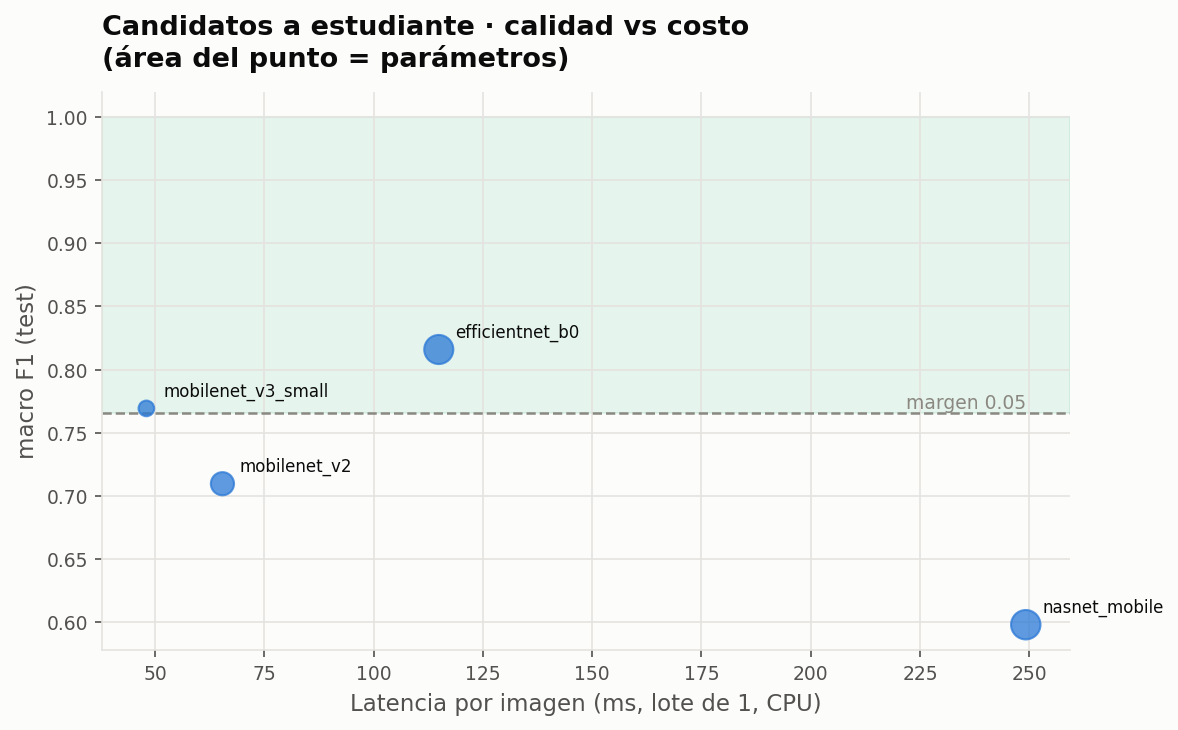

In [4]:
applyStyle()
import matplotlib.pyplot as plt

mejorF1 = comparacion["test_macro_f1"].max()
limite = mejorF1 - MARGEN_F1

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhspan(limite, 1.0, color=SERIE_3, alpha=0.10)
ax.axhline(limite, color=INK_MUTED, linestyle="--", linewidth=1.2)
ax.text(comparacion["latencia_ms"].max(), limite, f" margen {MARGEN_F1}",
        fontsize=9, va="bottom", ha="right", color=INK_MUTED)
ax.scatter(comparacion["latencia_ms"], comparacion["test_macro_f1"],
           s=comparacion["parametros_M"] * 40, color=SERIE_1, alpha=0.75, zorder=3)
for _, fila in comparacion.iterrows():
    ax.annotate(fila["arquitectura"], (fila["latencia_ms"], fila["test_macro_f1"]),
                textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.set(xlabel="Latencia por imagen (ms, lote de 1, CPU)", ylabel="macro F1 (test)",
       title="Candidatos a estudiante · calidad vs costo\n(área del punto = parámetros)")
fig.tight_layout()
plt.show()

## 3 · Estudiante elegido

In [5]:
candidatos = comparacion[comparacion["test_macro_f1"] >= limite]
elegido = candidatos.sort_values("latencia_ms").iloc[0]
run = runPorArquitectura[(elegido["arquitectura"], elegido["descongelado"])]

registro.writeJson(registro.OUTPUTS_DIR / "student.json", {
    "run_id": run["run_id"],
    "architecture": elegido["arquitectura"],
    "test_accuracy": float(elegido["test_accuracy"]),
    "test_macro_f1": float(elegido["test_macro_f1"]),
    "latencia_ms": float(elegido["latencia_ms"]),
    "parametros_M": float(elegido["parametros_M"]),
    "margen_f1": MARGEN_F1,
})

mejorFila = comparacion.iloc[0]
print(f"Dentro del margen: {list(candidatos['arquitectura'])}")
print(f"Estudiante: {elegido['arquitectura']} · macro-F1 {elegido['test_macro_f1']:.4f} "
      f"· {elegido['latencia_ms']:.0f} ms · {elegido['parametros_M']:.2f}M params")
if elegido["arquitectura"] != mejorFila["arquitectura"]:
    print(f"Cede {mejorFila['test_macro_f1'] - elegido['test_macro_f1']:.4f} de macro-F1 "
          f"frente a {mejorFila['arquitectura']}, a cambio de ser "
          f"{mejorFila['latencia_ms'] / elegido['latencia_ms']:.1f}x más rápido")

Dentro del margen: ['efficientnet_b0', 'mobilenet_v3_small']
Estudiante: mobilenet_v3_small · macro-F1 0.7691 · 48 ms · 1.41M params
Cede 0.0467 de macro-F1 frente a efficientnet_b0, a cambio de ser 2.4x más rápido


## Resumen

In [6]:
comparacion

,arquitectura,test_accuracy,test_macro_f1,parametros_M,tamano_MB,latencia_ms,minutos_entrenamiento,run_id
0,efficientnet_b0,0.827352,0.815861,4.88,27.1,114.9,207.2,20260906T173406Z_efficientnet-b0
1,mobilenet_v3_small,0.776431,0.769148,1.41,10.0,48.0,60.9,20260902T005147Z_mobilenet-v3-small
2,mobilenet_v2,0.724539,0.709435,3.09,19.6,65.4,102.7,20260906T151143Z_mobilenet-v2
3,nasnet_mobile,0.616392,0.597641,4.99,28.5,249.2,253.3,20260906T211535Z_nasnet-mobile
